# Transformer, random split - two hyperparameter configurations

Mentor's ask: random validation split, two hyperparameter sets, result
saved to a file. This is the transformer half of the three-model
comparison (see also `04_bilstm_random_split.ipynb` and
`05_lightgbm_random_split.ipynb`).

The split is the same well-grouped random split used in all three
notebooks (`models/random_split.py`) - 70/15/15 by well count, seed 42.
Everything else about the training loop (Huber loss, AdamW, OneCycle,
gradient clipping, early stopping on validation MAE) is unchanged from
`models/train_transformer.py`, which is what produced the year-split
numbers already in the week-5 review deck.

In [1]:
import sys
sys.path.insert(0, '../models')
import pandas as pd
import matplotlib.pyplot as plt
import train_random as tr
from transformer import RainTransformer, count_params

tr.CONFIGS['transformer']

{'a': {'d_model': 64,
  'layers': 3,
  'heads': 4,
  'patch': 4,
  'lr': 0.001,
  'bs': 512},
 'b': {'d_model': 32,
  'layers': 2,
  'heads': 4,
  'patch': 4,
  'lr': 0.002,
  'bs': 512}}

## Config A - the repo's existing default

`d_model` 64, 3 encoder layers, 4 heads, lr 1e-3 - the same architecture
used for the year-split numbers in `docs/06_transformer_explained.docx`
and the week-5 deck, just re-fit on the random split. Up to 12 epochs,
patience 4 (capped from the usual 25/5 for wall-clock reasons on this
2-core CPU box - no GPU here).

In [2]:
res_a = tr.run_transformer('a')
print('params:', res_a['params'], ' (176,817 on the year split; close but not identical here - same architecture, different split sizes feed the categorical embedding tables)')
print('epochs run:', res_a['epochs_run'], ' valid:', res_a['valid'], ' test:', res_a['test'])

[transformer-a] already in random_split_results.json - reusing it instead of retraining. Pass force=True to redo the run.
params: 176817  (176,817 on the year split; close but not identical here - same architecture, different split sizes feed the categorical embedding tables)
epochs run: 12  valid: {'mae': 1.415147066116333, 'rmse': 2.2238473892211914, 'r2': 0.5167685747146606}  test: {'mae': 1.4329663515090942, 'rmse': 2.259269952774048, 'r2': 0.48770809173583984}


## Config B - half the width, fewer layers, higher learning rate

`d_model` 32, 2 layers, lr 2e-3. Answers the same capacity question posed
on the BiLSTM side: does a transformer a fraction of the size land close
to the full one on this split?

In [3]:
res_b = tr.run_transformer('b')
print('params:', res_b['params'])
print('epochs run:', res_b['epochs_run'], ' valid:', res_b['valid'], ' test:', res_b['test'])

[transformer-b] already in random_split_results.json - reusing it instead of retraining. Pass force=True to redo the run.
params: 34865
epochs run: 12  valid: {'mae': 1.4103243350982666, 'rmse': 2.2171542644500732, 'r2': 0.5196729302406311}  test: {'mae': 1.4307446479797363, 'rmse': 2.253387212753296, 'r2': 0.4903724193572998}


## Comparing the two configs

In [4]:
rows = []
for name, r in [('transformer-a (d_model 64, 3 layers, lr 1e-3)', res_a),
                ('transformer-b (d_model 32, 2 layers, lr 2e-3)', res_b)]:
    rows.append(dict(config=name, params=r['params'], epochs_run=r['epochs_run'],
                      valid_mae=r['valid']['mae'], valid_r2=r['valid']['r2'],
                      test_mae=r['test']['mae'], test_r2=r['test']['r2'],
                      seconds=r['seconds']))
df = pd.DataFrame(rows)
df

,config,params,epochs_run,valid_mae,valid_r2,test_mae,test_r2,seconds
0,"transformer-a (d_model 64, 3 layers, lr 1e-3)",176817,12,1.415147,0.516769,1.432966,0.487708,1814.0
1,"transformer-b (d_model 32, 2 layers, lr 2e-3)",34865,12,1.410324,0.519673,1.430745,0.490372,625.2


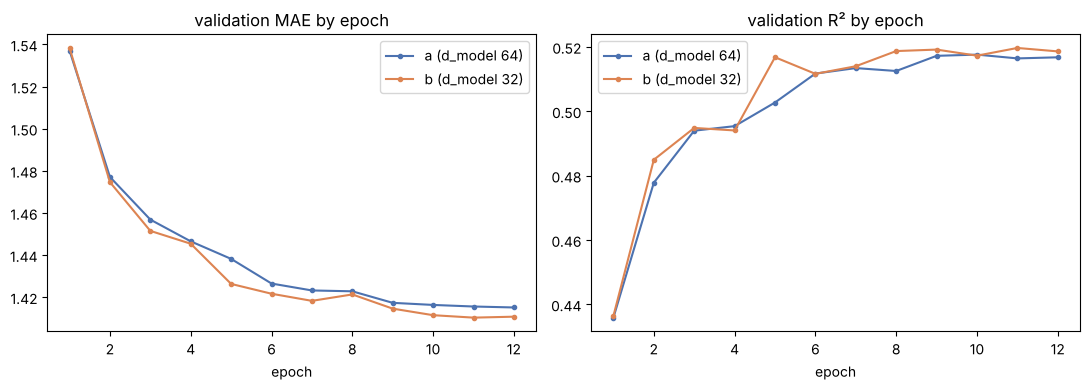

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for r, name, c in [(res_a, 'a (d_model 64)', '#4C72B0'), (res_b, 'b (d_model 32)', '#DD8452')]:
    h = pd.DataFrame(r['history'])
    ax[0].plot(h['epoch'], h['mae'], label=name, color=c, marker='o', ms=3)
    ax[1].plot(h['epoch'], h['r2'], label=name, color=c, marker='o', ms=3)
ax[0].set_title('validation MAE by epoch'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].set_title('validation R² by epoch'); ax[1].set_xlabel('epoch'); ax[1].legend()
plt.tight_layout()
plt.savefig('../reports/figures/random_split_transformer_curves.png', dpi=130)
plt.show()

## Random split vs the year-blocked split, for this architecture

The year-blocked numbers below are read from `data/training/results.json`
(the full 25-epoch run already in the repo). This is the single most
important chart for the review: it shows how much of any difference
between models is actually a difference between splits.

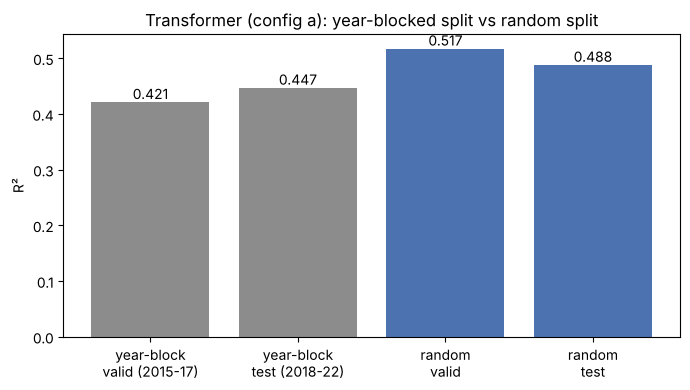

In [6]:
import json
year_split = json.load(open('../data/training/results.json'))
y_valid_r2 = year_split['transformer']['r2']
y_test_r2 = year_split['transformer_test']['r2']

labels = ['year-block\nvalid (2015-17)', 'year-block\ntest (2018-22)',
          'random\nvalid', 'random\ntest']
values = [y_valid_r2, y_test_r2, res_a['valid']['r2'], res_a['test']['r2']]
plt.figure(figsize=(7, 4))
bars = plt.bar(labels, values, color=['#8C8C8C', '#8C8C8C', '#4C72B0', '#4C72B0'])
for b, v in zip(bars, values):
    plt.text(b.get_x() + b.get_width()/2, v, f'{v:.3f}', ha='center', va='bottom')
plt.ylabel('R²')
plt.title('Transformer (config a): year-blocked split vs random split')
plt.tight_layout()
plt.savefig('../reports/figures/random_split_vs_year_split.png', dpi=130)
plt.show()

**Reading this:** the random split's R² sits well above the
year-blocked split's, for the *same architecture and the same features*.
That gap is the generalisation-difficulty gap between "predict a withheld
random 15% of wells" and "predict years the model has never seen the
climate of" - it says nothing about whether the transformer is a good
architecture, and should not be reported as if the model got better.
It's the same point the week-5 deck made about district folds (unseen
districts easier than unseen years) landing again on a different axis:
*random* is easier than *time*, and now also easier than *space*.

## Result

Both configs saved to `data/training/random_split_results.json` under
`transformer-a` / `transformer-b`.